In [1]:
import os
import random
import numpy as np
import pandas as pd
import torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Фиксация seed для воспроизводимости
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# Определение устройства (GPU или CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {device}")

Используемое устройство: cuda


In [2]:
# Загрузка датасета emotion
dataset = load_dataset("dair-ai/emotion")

print("Размеры split-частей:")
print(f"Train: {dataset['train'].num_rows}")
print(f"Validation: {dataset['validation'].num_rows}")
print(f"Test: {dataset['test'].num_rows}\n")

labels_names = dataset["train"].features["label"].names
print(f"Названия классов: {labels_names}\n")

print("Примеры текстов и меток (Train):")
for i in range(3):
    sample = dataset["train"][i]
    print(f"Текст {i+1}: {sample['text']}")
    print(f"Метка {i+1}: {sample['label']} ({labels_names[sample['label']]})\n")

Размеры split-частей:
Train: 16000
Validation: 2000
Test: 2000

Названия классов: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

Примеры текстов и меток (Train):
Текст 1: i didnt feel humiliated
Метка 1: 0 (sadness)

Текст 2: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
Метка 2: 0 (sadness)

Текст 3: im grabbing a minute to post i feel greedy wrong
Метка 3: 3 (anger)



In [3]:
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

print("Базовый разбор токенизации на 3 текстах:\n")
sample_texts = dataset["train"]["text"][:3]

for i, text in enumerate(sample_texts):
    print(f"Оригинальный текст {i+1}: {text}")
    
    # Токенизация с padding и truncation
    encoded = tokenizer(text, padding="max_length", truncation=True, max_length=20, return_tensors="pt")
    
    tokens = tokenizer.convert_ids_to_tokens(encoded["input_ids"][0])
    
    print(f"Токены: {tokens}")
    print(f"input_ids: {encoded['input_ids'][0].tolist()}")
    print(f"attention_mask: {encoded['attention_mask'][0].tolist()}")
    print("-" * 50)

Базовый разбор токенизации на 3 текстах:

Оригинальный текст 1: i didnt feel humiliated
Токены: ['[CLS]', 'i', 'didn', '##t', 'feel', 'humiliated', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
input_ids: [101, 1045, 2134, 2102, 2514, 26608, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
attention_mask: [1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
--------------------------------------------------
Оригинальный текст 2: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
Токены: ['[CLS]', 'i', 'can', 'go', 'from', 'feeling', 'so', 'hopeless', 'to', 'so', 'damned', 'hopeful', 'just', 'from', 'being', 'around', 'someone', 'who', 'cares', '[SEP]']
input_ids: [101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 2061, 9636, 17772, 2074, 2013, 2108, 2105, 2619, 2040, 14977, 102]
attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 

In [4]:
untrained_model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=6).to(device)
untrained_model.eval()

print("Инференс 'из коробки' (до обучения):\n")
with torch.no_grad():
    for i, text in enumerate(sample_texts):
        # Токенизируем текст и отправляем на видеокарту
        inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True).to(device)
        
        # Получаем сырые предсказания
        outputs = untrained_model(**inputs)
        logits = outputs.logits
        
        # Выбираем класс с максимальной вероятностью
        predicted_class_id = logits.argmax().item()
        
        print(f"Текст: {text}")
        print(f"Истинная метка: {dataset['train']['label'][i]} ({labels_names[dataset['train']['label'][i]]})")
        print(f"Предсказание модели: {predicted_class_id} ({labels_names[predicted_class_id]})\n")

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Инференс 'из коробки' (до обучения):

Текст: i didnt feel humiliated
Истинная метка: 0 (sadness)
Предсказание модели: 3 (anger)

Текст: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
Истинная метка: 0 (sadness)
Предсказание модели: 3 (anger)

Текст: im grabbing a minute to post i feel greedy wrong
Истинная метка: 3 (anger)
Предсказание модели: 3 (anger)



In [5]:
# 1. Функция токенизации для всего датасета
def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=64)

print("Токенизация данных ...")
tokenized_datasets = dataset.map(tokenize_function, batched=True)

# 2. Функция для подсчета метрик (Accuracy и F1 Macro)
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average="macro")
    return {"accuracy": acc, "f1_macro": f1}

# 3. Настройка параметров обучения
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",       
    save_strategy="epoch",       
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=2,          
    weight_decay=0.01,
    load_best_model_at_end=True, 
    metric_for_best_model="f1_macro",
    seed=42,
    report_to="none"          
)

# 4. Инициализация тренера
trainer = Trainer(
    model=untrained_model,       
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    compute_metrics=compute_metrics,
)

# 5. Запуск обучения
trainer.train()

Токенизация данных ...


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.607800,0.218437,0.920000,0.891366
2,0.167700,0.161155,0.939500,0.910879


TrainOutput(global_step=1000, training_loss=0.38772427368164064, metrics={'train_runtime': 126.6787, 'train_samples_per_second': 252.608, 'train_steps_per_second': 7.894, 'total_flos': 529907392512000.0, 'train_loss': 0.38772427368164064, 'epoch': 2.0})

Оценка модели на тестовой выборке...



--- Результаты на TEST ---
Accuracy: 0.9200
F1-Macro: 0.8672



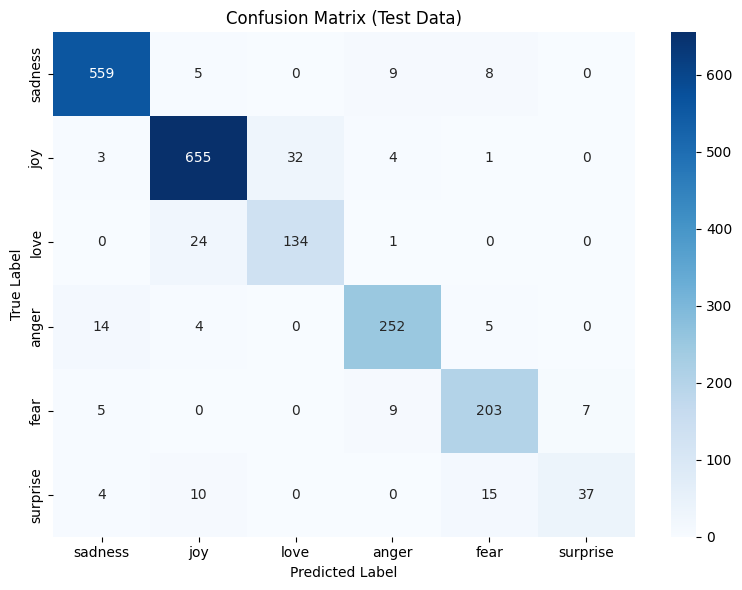


--- Примеры ошибок (Анализ) ---
Текст: i don t feel particularly agitated
Ожидали: fear | Модель выдала: anger (Уверенность: 0.73)

Текст: i feel a bit stressed even though all the things i have going on are fun
Ожидали: anger | Модель выдала: sadness (Уверенность: 0.57)

Текст: i am right handed however i play billiards left handed naturally so me trying to play right handed feels weird
Ожидали: surprise | Модель выдала: fear (Уверенность: 0.57)

Текст: i feel like i am in paradise kissing those sweet lips make me feel like i dive into a magical world of love
Ожидали: joy | Модель выдала: love (Уверенность: 0.55)

Текст: when a friend dropped a frog down my neck
Ожидали: anger | Модель выдала: fear (Уверенность: 0.65)



In [6]:
# 1. Финальный прогон на тестовой выборке
print("Оценка модели на тестовой выборке...")
test_results = trainer.predict(tokenized_datasets["test"])
predictions = np.argmax(test_results.predictions, axis=-1)
true_labels = test_results.label_ids

# 2. Вывод метрик
print("\n--- Результаты на TEST ---")
print(f"Accuracy: {test_results.metrics['test_accuracy']:.4f}")
print(f"F1-Macro: {test_results.metrics['test_f1_macro']:.4f}\n")

# 3. Построение и сохранение матрицы ошибок
cm = confusion_matrix(true_labels, predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels_names, yticklabels=labels_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Test Data)")
plt.tight_layout()
plt.savefig("artifacts/confusion_matrix.png") 
plt.show()

# 4. Подготовка sample_predictions.csv
test_texts = dataset["test"]["text"]
# Считаем уверенность модели (confidence) через softmax
confidence_scores = torch.nn.functional.softmax(torch.tensor(test_results.predictions), dim=-1)
confidences = confidence_scores.max(dim=-1).values.numpy()

df_preds = pd.DataFrame({
    "text": test_texts,
    "true_label": [labels_names[l] for l in true_labels],
    "pred_label": [labels_names[p] for p in predictions],
    "confidence": confidences
})
df_preds.to_csv("artifacts/sample_predictions.csv", index=False)

# 5. Краткий анализ ошибок
errors_df = df_preds[df_preds["true_label"] != df_preds["pred_label"]].head(5)
print("\n--- Примеры ошибок (Анализ) ---")
for _, row in errors_df.iterrows():
    print(f"Текст: {row['text']}")
    print(f"Ожидали: {row['true_label']} | Модель выдала: {row['pred_label']} (Уверенность: {row['confidence']:.2f})\n")